# 🚢 타이타닉 데이터셋 기초 EDA (탐색적 데이터 분석)

이 주피터 노트북은 데이터 분석을 처음 시작하는 분들을 위해 작성되었습니다.
데이터 분석의 가장 첫 단계인 **데이터 품질 검증(결측치, 중복값, 이상치 확인)**을 한 셀씩 실행하며 실습합니다.

> 💡 **단축키 안내**:
> - `Shift + Enter`: 현재 셀 실행 후 다음 셀로 이동
> - `Ctrl + Enter`: 현재 셀 실행만 수행
> - `Esc` + `B`: 아래에 새로운 셀 추가
> - `Esc` + `D, D`: 선택한 셀 삭제

## 1. 필수 라이브러리 임포트 및 시각화 환경 설정
- `pandas`: 표 형태의 데이터(DataFrame)를 다루는 라이브러리
- `numpy`: 수치 연산 라이브러리
- `matplotlib`, `seaborn`: 데이터 시각화 라이브러리

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기본 맑은 고딕)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 차트 스타일 설정
sns.set_theme(style='whitegrid', font='Malgun Gothic')

print("[V] 라이브러리 임포트 및 한글 폰트 설정 완료!")

[V] 라이브러리 임포트 및 한글 폰트 설정 완료!


## 2. 데이터 불러오기 및 기본 정보 확인
`data/train_and_test2.csv` 파일을 불러온 후 행과 열의 크기, 상위 5개 행을 확인합니다.

In [2]:
# 데이터 불러오기
data_path = os.path.join("data", "train_and_test2.csv")
df = pd.read_csv(data_path)

# 주요 유의미한 컬럼만 선별하고 생존 컬럼명 정리
main_cols = ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', '2urvived']
df_clean = df[[c for c in main_cols if c in df.columns]].copy()
if '2urvived' in df_clean.columns:
    df_clean.rename(columns={'2urvived': 'Survived'}, inplace=True)

print(f"총 데이터 크기: {df_clean.shape[0]}행 x {df_clean.shape[1]}열")
df_clean.head()

총 데이터 크기: 1309행 x 9열


,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


## 3. 결측치(Missing Values) 검증
데이터에 값이 비어있는 칸(`NaN`)이 있는지 확인합니다.
머신러닝 모델이나 통계 함수는 결측치가 있으면 동작하지 않기 때문에 필수 점검 사항입니다.

=== 결측치가 있는 컬럼 ===


,결측치_개수,결측치_비율(%)
Embarked,2,0.15


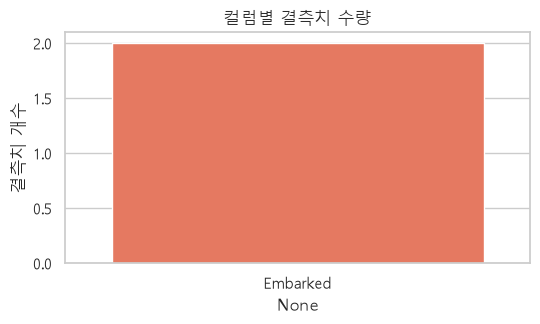

In [3]:
# 각 컬럼별 결측치 개수 및 비율 확인
missing_counts = df_clean.isnull().sum()
missing_percent = (missing_counts / len(df_clean)) * 100

missing_df = pd.DataFrame({
    '결측치_개수': missing_counts,
    '결측치_비율(%)': missing_percent.round(2)
})

print("=== 결측치가 있는 컬럼 ===")
missing_detected = missing_df[missing_df['결측치_개수'] > 0]
display(missing_detected)

# 결측치 시각화 (막대 차트)
plt.figure(figsize=(6, 3))
if not missing_detected.empty:
    sns.barplot(x=missing_detected.index, y=missing_detected['결측치_개수'], palette='Reds_r', hue=missing_detected.index, legend=False)
    plt.title('컬럼별 결측치 수량')
    plt.ylabel('결측치 개수')
    plt.show()
else:
    print("결측치가 0건입니다.")

## 4. 중복값(Duplicates) 검증
데이터셋에 완전히 동일한 행이 중복되어 있는지 점검합니다.

In [4]:
# 1) 전체 행 중복 확인
row_duplicates = df_clean.duplicated().sum()
# 2) 승객 고유 ID 중복 확인
id_duplicates = df_clean.duplicated(subset=['Passengerid']).sum()

print(f"• 전체 행 완전 일치 중복: {row_duplicates}건")
print(f"• 승객 고유번호(Passengerid) 중복: {id_duplicates}건")

if row_duplicates == 0 and id_duplicates == 0:
    print("\n[V] 중복값이 전혀 없으므로 데이터 무결성이 우수합니다.")

• 전체 행 완전 일치 중복: 0건
• 승객 고유번호(Passengerid) 중복: 0건

[V] 중복값이 전혀 없으므로 데이터 무결성이 우수합니다.


## 5. 이상치(Outliers) 검증 - IQR(사분위 범위) 및 Boxplot
데이터에서 일반적인 범위를 벗어난 극단적인 수치를 확인합니다.
- **IQR** = $Q_3(75\%) - Q_1(25\%)$
- **정상 범위**: $[Q_1 - 1.5 \times IQR \sim Q_3 + 1.5 \times IQR]$
- 상자 수염 그림(Boxplot)의 바깥에 찍히는 점들이 이상치 후보입니다.

In [5]:
def analyze_outliers(df, column_name):
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = df[(df[column_name] < lower) | (df[column_name] > upper)]
    print(f"[{column_name}]")
    print(f"  - 1사분위(25%): {q1:.2f}, 3사분위(75%): {q3:.2f}, IQR: {iqr:.2f}")
    print(f"  - 정상 범위: [{lower:.2f} ~ {upper:.2f}]")
    print(f"  - 이상치 개수: {len(outliers)}건 ({len(outliers)/len(df)*100:.2f}%)")
    return lower, upper

print("=== 연속형 변수 이상치 분석 ===")
lower_age, upper_age = analyze_outliers(df_clean, 'Age')
print()
lower_fare, upper_fare = analyze_outliers(df_clean, 'Fare')

=== 연속형 변수 이상치 분석 ===
[Age]
  - 1사분위(25%): 22.00, 3사분위(75%): 35.00, IQR: 13.00
  - 정상 범위: [2.50 ~ 54.50]
  - 이상치 개수: 101건 (7.72%)

[Fare]
  - 1사분위(25%): 7.90, 3사분위(75%): 31.27, IQR: 23.38
  - 정상 범위: [-27.17 ~ 66.34]
  - 이상치 개수: 171건 (13.06%)


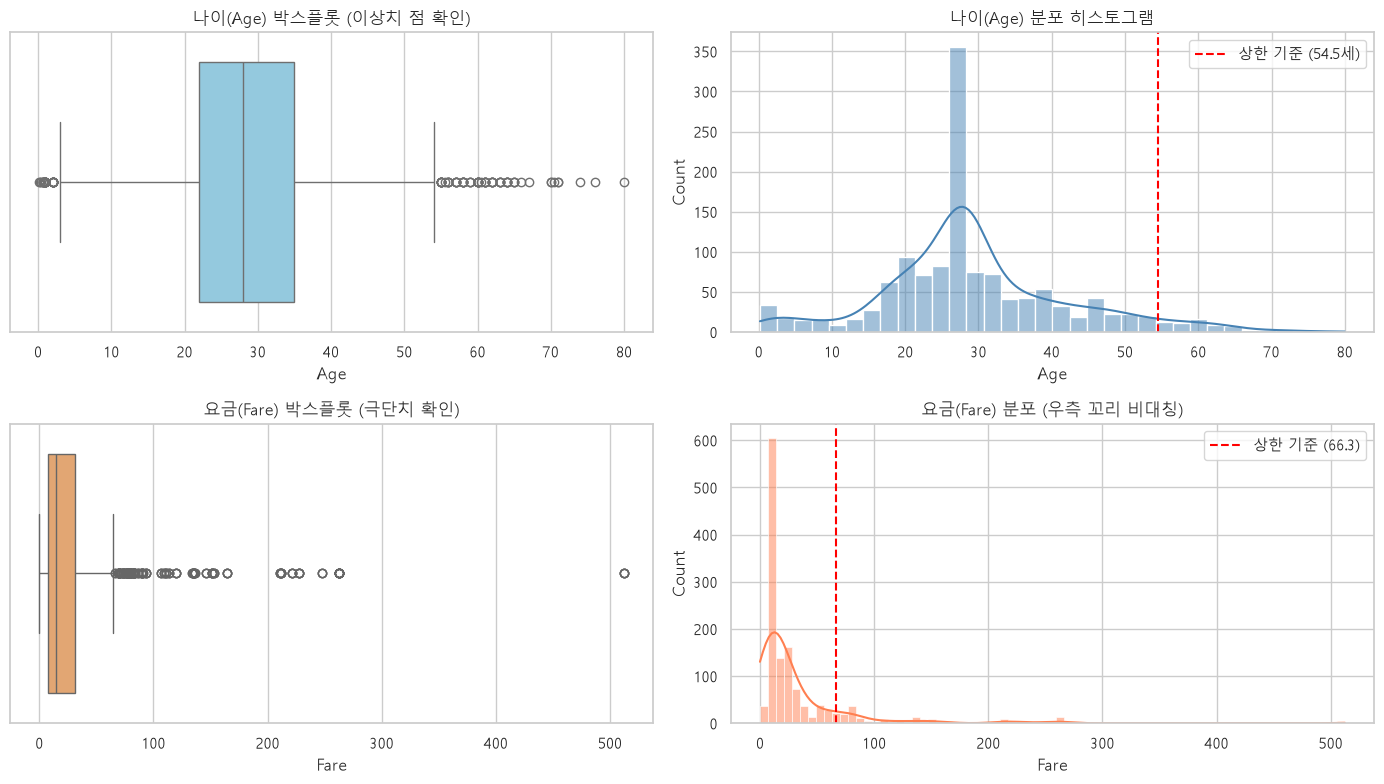

In [6]:
# 나이와 요금의 Boxplot 및 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 나이 Boxplot & 히스토그램
sns.boxplot(x=df_clean['Age'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('나이(Age) 박스플롯 (이상치 점 확인)')

sns.histplot(df_clean['Age'], kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].axvline(upper_age, color='red', linestyle='--', label=f'상한 기준 ({upper_age:.1f}세)')
axes[0, 1].set_title('나이(Age) 분포 히스토그램')
axes[0, 1].legend()

# 요금 Boxplot & 히스토그램
sns.boxplot(x=df_clean['Fare'], ax=axes[1, 0], color='sandybrown')
axes[1, 0].set_title('요금(Fare) 박스플롯 (극단치 확인)')

sns.histplot(df_clean['Fare'], kde=True, ax=axes[1, 1], color='coral')
axes[1, 1].axvline(upper_fare, color='red', linestyle='--', label=f'상한 기준 ({upper_fare:.1f})')
axes[1, 1].set_title('요금(Fare) 분포 (우측 꼬리 비대칭)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 6. 결론 및 다음 단계
1. **결측치**: `Embarked` 2건 결측치 -> 최빈값(2.0)으로 채우기(`df['Embarked'].fillna()`) 권장
2. **중복값**: 없음
3. **이상치**: 요금(`Fare`)의 극단값은 1등석 특등실 승객의 실제 요금이므로 함부로 삭제하지 않고 로그 스케일링 권장

🎉 **다음 실습 추천**: 성별(`Sex`)과 객실등급(`Pclass`)에 따른 생존율(`Survived`) 피벗 테이블 및 그룹별 시각화!